#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

#### Load your Dataset

In [3]:
df_car=pd.read_csv('Car details v3.csv')

In [4]:
df=df_car.copy()

In [5]:
df['selling_price'].max()

10000000

In [165]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


#### Dimension of Data

In [166]:
df.shape

(8128, 13)

In [167]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


#### Visualize Skewness

In [169]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [170]:
df.describe(include='all')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


#### Dataset important Information 

In cars, torque is essentially the engine's rotational force, often described as its "twisting power" or "pulling power". It determines how much force the engine can exert to turn the wheels, impacting acceleration and the ability to tow or haul heavy loads. Higher torque means quicker acceleration, especially from a standstill, and better performance when pulling or carrying weight

In [171]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [172]:
df['engine'].isnull().sum()

np.int64(221)

#### Data Cleaning

In this part we will remove the textual part of our data because our machine learning model just works wiuth numerical values
it does not works with textual textual unit actauuly confuses our model in order to perform final prediction

In [173]:
df['engine']=df['engine'].str.replace('CC','');
df['engine']=pd.to_numeric(df['engine'])

In [174]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [175]:
df['mileage_unit'] = df['mileage'].apply(
    lambda x: 'km/kg' if isinstance(x, str) and 'km/kg' in x else 
              ('kmpl' if isinstance(x, str) and 'kmpl' in x else 'unknown')
)

kmkg_count = (df['mileage_unit'] == 'km/kg').sum()
print(f"Total rows with km/kg unit: {kmkg_count}")

Total rows with km/kg unit: 88


In [176]:
df['mileage_value'] = df['mileage'].apply(
    lambda x: x.replace('km/kg', '').replace('kmpl', '') if isinstance(x, str) else x
)
df['mileage_value'] = pd.to_numeric(df['mileage_value'], errors='coerce')

# km/kg ko kmpl me convert karo
df.loc[df['mileage_unit'] == 'km/kg', 'mileage_value'] *= 1.4

In [177]:
df.drop(df[['mileage_unit','mileage']],axis=1,inplace=True)

In [178]:
df['max_power']=df['max_power'].str.replace('bhp','')
df['max_power']=pd.to_numeric(df['max_power'],errors='coerce')

#### Drop Columns

In [179]:
df.drop('name',axis=1,inplace=True)

In [180]:
df.drop('seats',axis=1,inplace=True)

In [181]:
df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,engine,max_power,torque,mileage_value
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,1248.0,74.00,190Nm@ 2000rpm,23.40
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,1498.0,103.52,250Nm@ 1500-2500rpm,21.14
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",17.70
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,1396.0,90.00,22.4 kgm at 1750-2750rpm,23.00
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",16.10
...,...,...,...,...,...,...,...,...,...,...,...
8123,2013,320000,110000,Petrol,Individual,Manual,First Owner,1197.0,82.85,113.7Nm@ 4000rpm,18.50
8124,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",16.80
8125,2009,382000,120000,Diesel,Individual,Manual,First Owner,1248.0,73.90,190Nm@ 2000rpm,19.30
8126,2013,290000,25000,Diesel,Individual,Manual,First Owner,1396.0,70.00,140Nm@ 1800-3000rpm,23.57


#### Check Skewness in Columns

In [182]:
df.skew(numeric_only=True)
#if the value of skewness is greater than zero then our data is right skewed and 
#if the value is less than zero than data is left skewed

year             -1.072293
selling_price     4.193533
km_driven        11.170910
engine            1.135269
max_power         1.621261
mileage_value     0.311338
dtype: float64

### Visualize Skewness in Dataset

#### Histogram

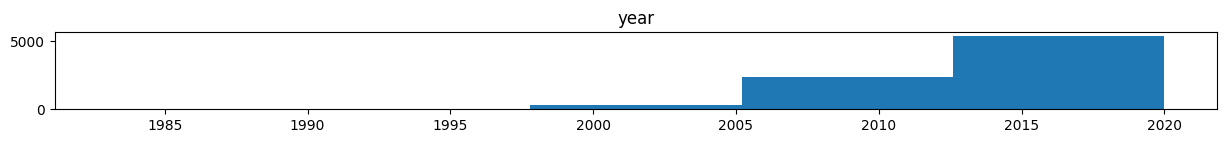

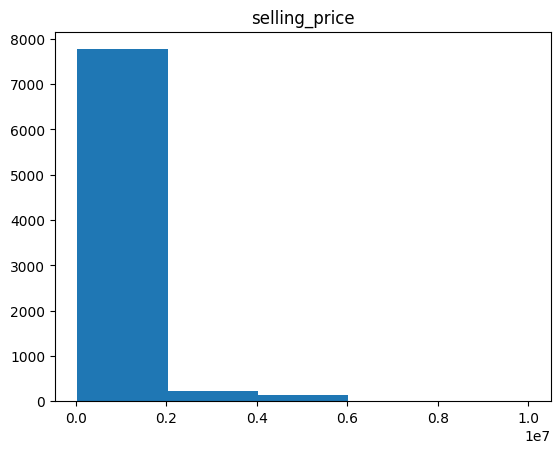

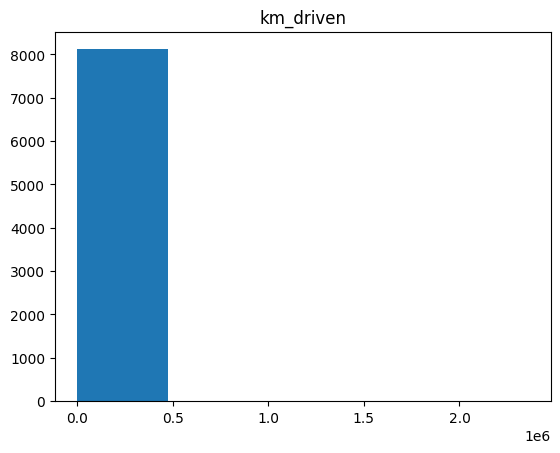

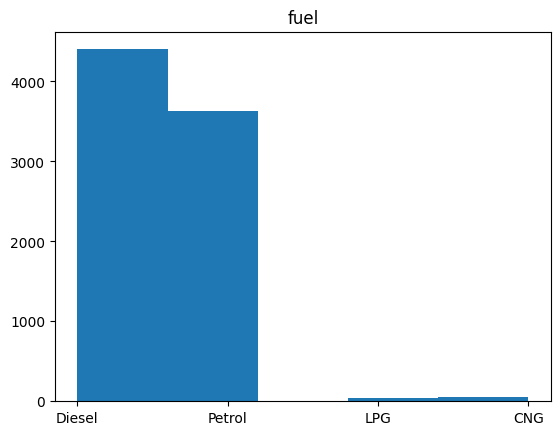

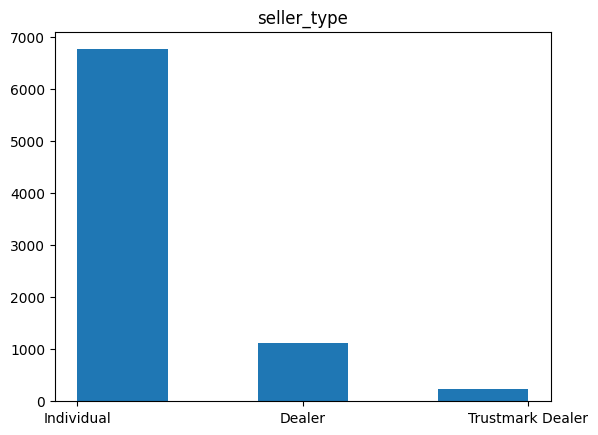

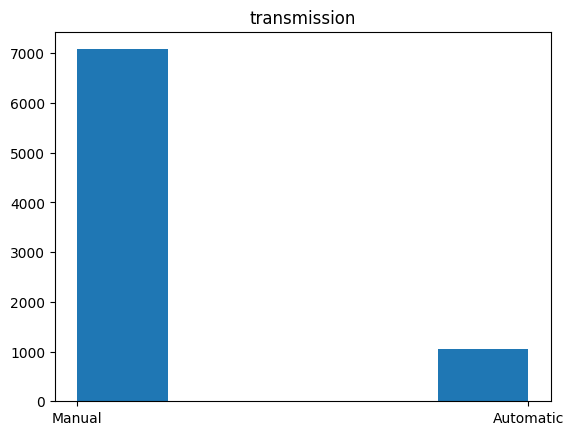

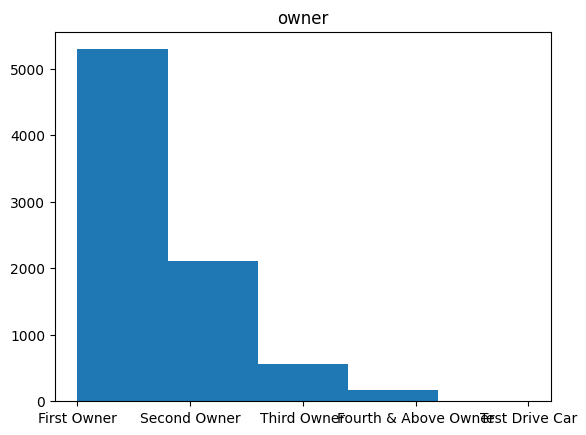

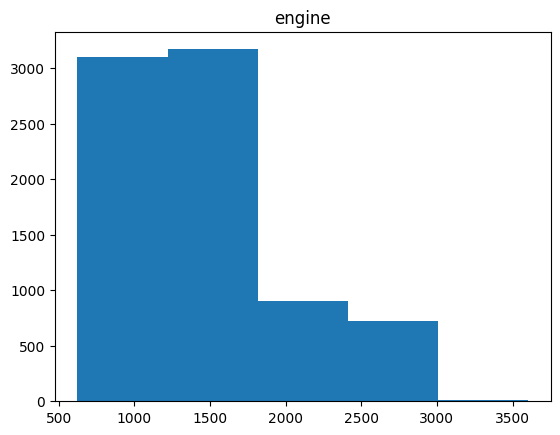

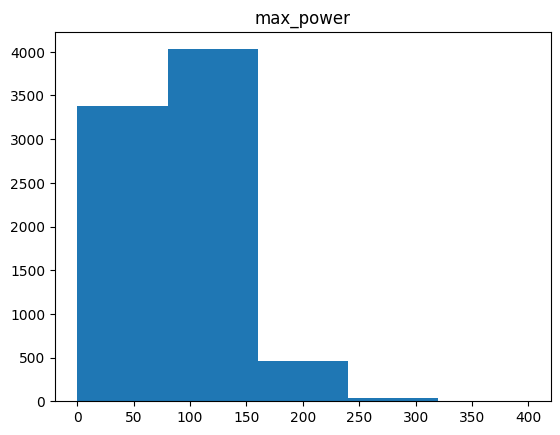

TypeError: 'value' must be an instance of str or bytes, not a float

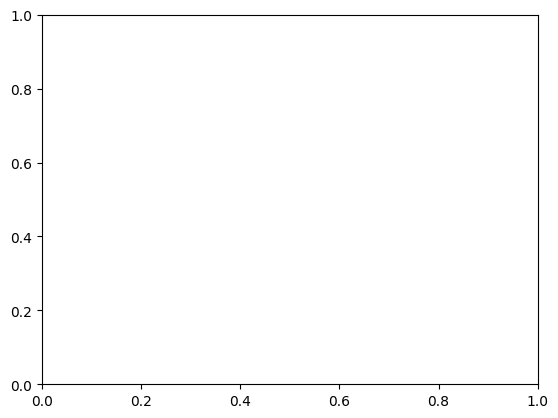

In [183]:
plt.figure(figsize=(15,1))

for col in df.columns:

    plt.hist(df[col],bins=5)

    plt.title(col)

    plt.show();

#### Important Pont for Skewness

if the value of skewness is greater than 1 than it means your data is highly right skewed and if the skewness is less than -1 then it means data is highly negative skewed you ahve to aply transfornations on it

#### Visualizing Outliers in Dataset

In [ ]:
for col in df.columns:
    plt.figure(figsize=(6,1))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df.shape

#### Remove Skewness from Dataset

log transformtaion is used when feature is highly positive skewed and sqrt transformation is used when data is mild skewed and when data is left skewed then we use yeo johnson technique and cube root transformtaion and square transformnation Acoording to my Data I have to remove skewness from teh four features my data which are the follwoing columns year,selling_price,km_driven,engine,seats

In [ ]:
df.skew(numeric_only=True)

In [ ]:
df['selling_price']=np.log1p(df['selling_price'])

In [ ]:
df['selling_price'].skew()

In [ ]:
df['km_driven']=np.sqrt(df['km_driven'])

In [ ]:
df['km_driven'].skew()

In [ ]:
df['year']=np.power(df['year'],2)

In [ ]:
df['year'].skew()

In [ ]:
df['engine']=np.sqrt(df['engine'])

In [ ]:
df['engine'].skew()

In [ ]:
sns.boxplot(x=df['selling_price'])

### Visualize Columns After Skewness 

#### Histogram

In [ ]:
plt.figure(figsize=(15,2))

for col in df.columns:

    plt.hist(df[col],bins=5)

    plt.title(col)

    plt.show();
           

#### Filling the columns with Null Values

In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

#### Filling Null Values

In [ ]:
median_engine=df['engine'].median()
power=df['max_power'].median()
mileage=df['mileage_value'].median()

In [ ]:
df['engine']=df['engine'].fillna(median_engine)
df['max_power']=df['max_power'].fillna(power)
df['mileage_value']=df['mileage_value'].fillna(mileage)

In [ ]:
df.isnull().sum()

In [ ]:
df.columns

#### Visualizing Categories in Data

In [ ]:
sns.countplot(x='owner',data=df);

In [ ]:
sns.countplot(x='seller_type',data=df);

In [ ]:
sns.countplot(x=df['transmission']);

#### Plotting Scatter Plot

When we are using scatter plot our main purpose is to find the correlation of the input feature with target variable and if 
data points are occuring on a line then it means there exists a correlations between that input feature and target variable

In [ ]:
plt.scatter(x='owner',y='selling_price',data=df);

plt.xlabel('Owner')

plt.ylabel('Selling Price')

plt.title('Selling Price Vs Owner')

plt.show();

#it has no correlation with target variable as it is clear from the insight

#### Anova Test for this feature 

In [ ]:
from scipy.stats import f_oneway

first_owner=df[df['owner']=='First Owner']['selling_price']
second_owner=df[df['owner']=='Second Owner']['selling_price']
third_owner=df[df['owner']=='Third Owner']['selling_price']
fourth_owner=df[df['owner']=='Fourth & Above Owner']['selling_price']
fifth_owner=df[df['owner']=='Test Drive Car']['selling_price']

f_stat,p_val=f_oneway(first_owner,second_owner,third_owner,fourth_owner,fifth_owner)

print(p_val)
#here p_val is 0 which means that this column has a significant relation with our targte variable
print(f_stat)

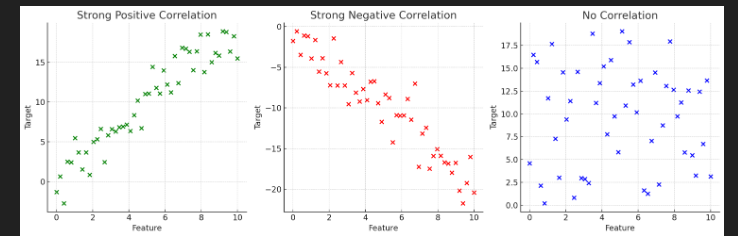

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x='seller_type', y='selling_price',data=df)
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Feature vs Target Scatter Plot")
plt.show()


#### Here we are unable to find any insight from this scatter plot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: 'seller_type' categorical feature aur 'selling_price' target
sns.boxplot(x='seller_type', y='selling_price', data=df)

plt.title('Selling Price vs Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.show()


In [ ]:
plt.scatter(x='year',y='selling_price',data=df);

plt.xlabel('Year')

plt.ylabel('Price')

plt.show()
#Year has a strong correlation with target feature

#### Creating Scatter Plot for All Columns 

In [ ]:
df.columns

In [ ]:
columns=['year', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'engine', 'max_power', 'mileage_value']

In [ ]:
plt.figure(figsize=(4,1))
for feature in columns:

    plt.scatter(x=feature,y='selling_price',data=df)

    plt.xlabel(feature)

    plt.ylabel('Price')
    
    plt.show()

### Box Plot for Fuel and Transmission Feature

#### Anova Test

When we are unable to predict the relations of input feature with the target variable by usinmg scatter plot ot box plot  then we perform Anova test if the p_value of Anova test is less than 0.5 then it means input feature has a strong relation with the target variable but if the p_value is greater than or equal to 0.5 tehn it means target variable has no relation with that input feature  

In [ ]:
from scipy.stats import f_oneway

#Make Groups

individual_prices=df[df['seller_type']=='Individual']['selling_price']

dealer_prices=df[df['seller_type']=='Dealer']['selling_price']

trust_mark=df[df['seller_type']=='Trustmark Dealer']['selling_price']
    
#Anova test

f_stat,p_value=f_oneway(individual_prices,dealer_prices,trust_mark)

print(f'P_value : {p_value}')
print(f'f Statistics : {f_stat}')

In [ ]:
#Groups

manual=df[df['transmission']=='Manual']['selling_price']

auto=df[df['transmission']=='Automatic']['selling_price']

f_stat,p_value=f_oneway(manual,auto)

print(p_value)
#Tranmission column hs a significant relationship in order to preodct target feature selling price

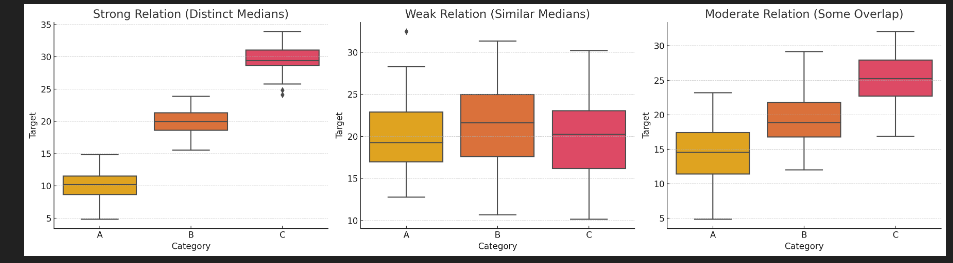

In [ ]:
sns.boxplot(x='transmission',y='selling_price',data=df);

#### Creating Box Plot for all representations

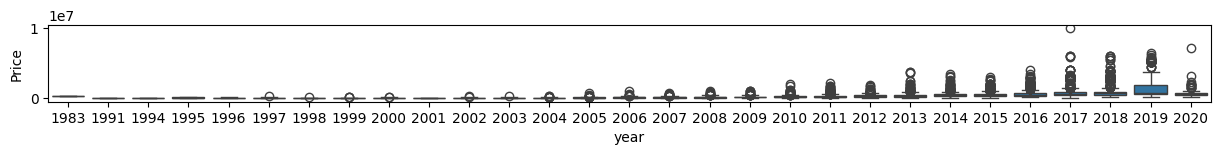

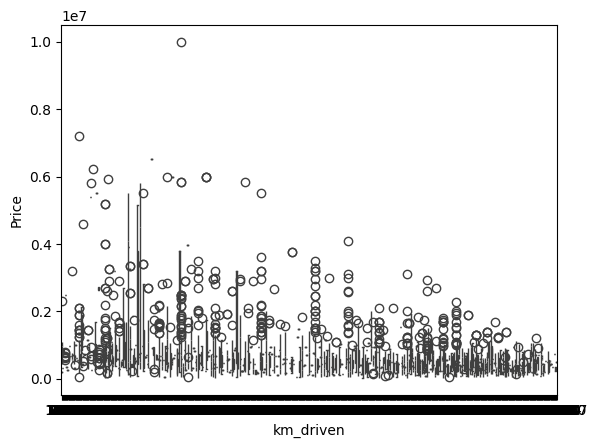

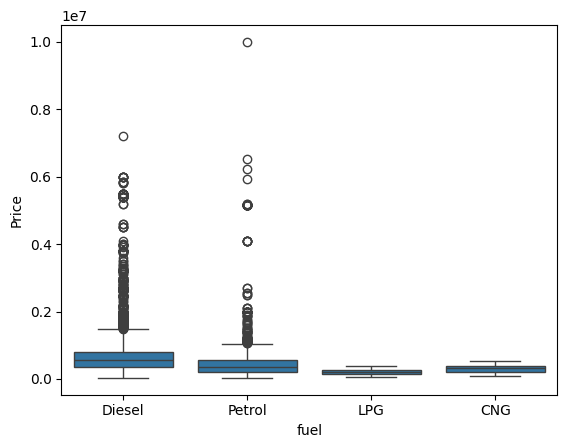

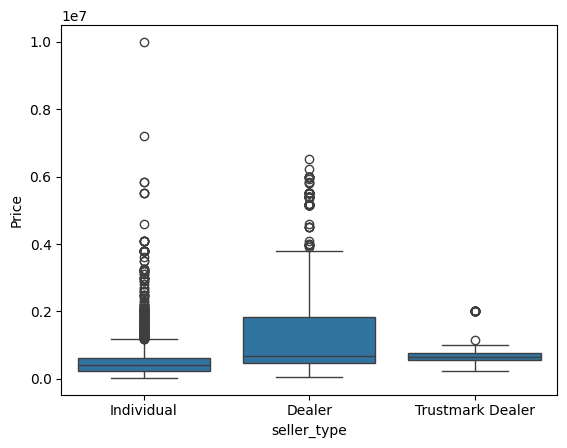

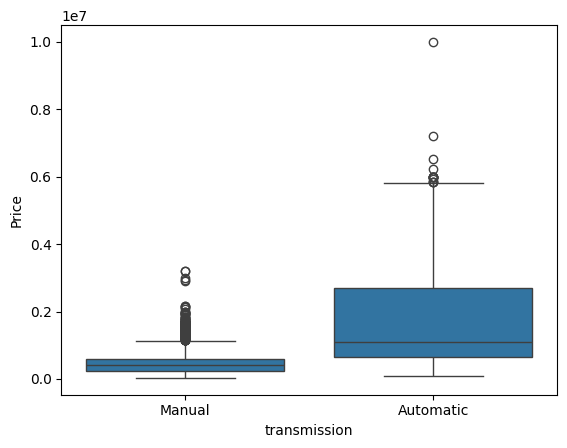

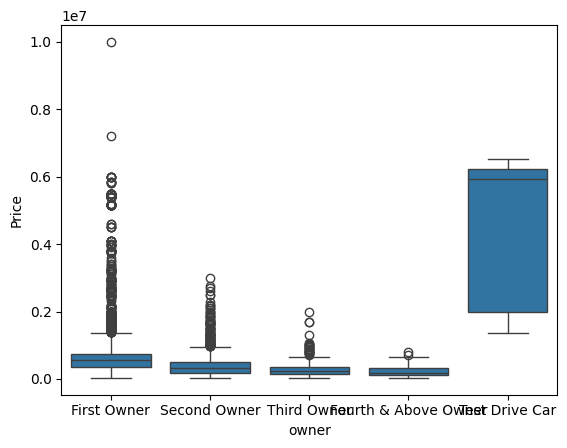

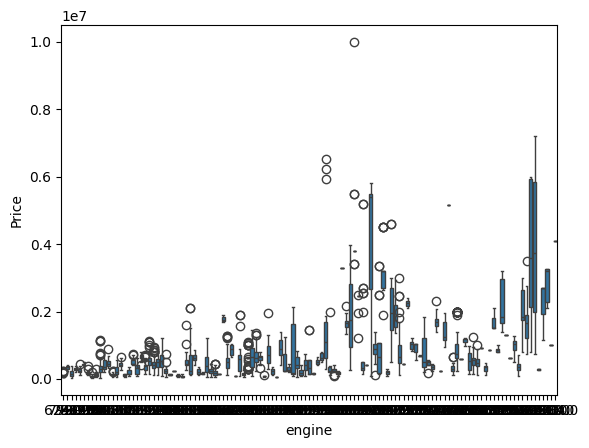

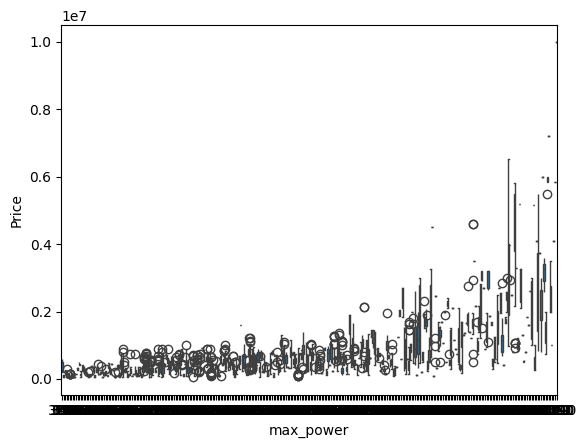

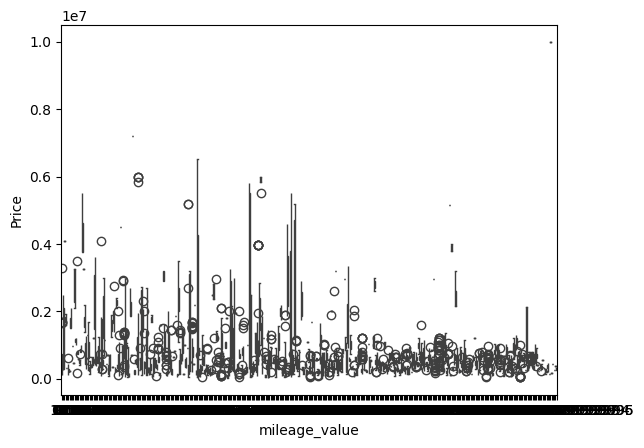

In [184]:
plt.figure(figsize=(15,1))

for feature in columns:

    sns.boxplot(x=feature,y='selling_price',data=df)

    plt.xlabel(feature)

    plt.ylabel('Price')
    
    plt.show()

In [185]:
df.drop('seller_type',axis=1,inplace=True)
df.drop('torque',axis=1,inplace=True)

In [186]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner',
       'engine', 'max_power', 'mileage_value'],
      dtype='object')

In [187]:
df.describe()

,year,selling_price,km_driven,engine,max_power,mileage_value
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7912.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,1458.625016,91.517919,19.516468
std,4.044249,8.062534e+05,5.655055e+04,503.916303,35.822499,4.244400
min,1983.000000,2.999900e+04,1.000000e+00,624.000000,0.000000,0.000000
25%,2011.000000,2.549990e+05,3.500000e+04,1197.000000,68.050000,16.780000
50%,2015.000000,4.500000e+05,6.000000e+04,1248.000000,82.000000,19.330000
75%,2017.000000,6.750000e+05,9.800000e+04,1582.000000,102.000000,22.320000
max,2020.000000,1.000000e+07,2.360457e+06,3604.000000,400.000000,46.816000


In [188]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner',
       'engine', 'max_power', 'mileage_value'],
      dtype='object')

In [189]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

#### Analyzing Correlations

In [190]:
df.dtypes

year               int64
selling_price      int64
km_driven          int64
fuel              object
transmission      object
owner             object
engine           float64
max_power        float64
mileage_value    float64
dtype: object

In [191]:
integers=df.select_dtypes(include=('int64','float64'))

In [192]:
integers.corr()

,year,selling_price,km_driven,engine,max_power,mileage_value
year,1.000000,0.414092,-0.418006,0.018848,0.226320,0.312216
selling_price,0.414092,1.000000,-0.225534,0.455734,0.748489,-0.130221
km_driven,-0.418006,-0.225534,1.000000,0.205914,-0.038075,-0.163628
engine,0.018848,0.455734,0.205914,1.000000,0.703975,-0.566641
max_power,0.226320,0.748489,-0.038075,0.703975,1.000000,-0.376993
mileage_value,0.312216,-0.130221,-0.163628,-0.566641,-0.376993,1.000000


In [193]:
df.shape

(8128, 9)

In [194]:
df.drop('engine',axis=1,inplace=True)
df.drop('mileage_value',axis=1,inplace=True)

In [195]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner',
       'max_power'],
      dtype='object')

In [196]:
df['transmission'].value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

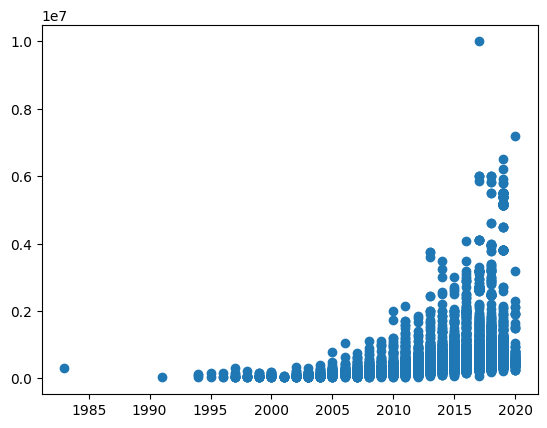

In [197]:
plt.scatter(x='year',y='selling_price',data=df);

In [198]:
df.drop('owner',axis=1,inplace=True)

In [199]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'transmission',
       'max_power'],
      dtype='object')

In [200]:
df.describe()

,year,selling_price,km_driven,max_power
count,8128.000000,8.128000e+03,8.128000e+03,7912.000000
mean,2013.804011,6.382718e+05,6.981951e+04,91.517919
std,4.044249,8.062534e+05,5.655055e+04,35.822499
min,1983.000000,2.999900e+04,1.000000e+00,0.000000
25%,2011.000000,2.549990e+05,3.500000e+04,68.050000
50%,2015.000000,4.500000e+05,6.000000e+04,82.000000
75%,2017.000000,6.750000e+05,9.800000e+04,102.000000
max,2020.000000,1.000000e+07,2.360457e+06,400.000000


In [201]:
med_power=df['max_power'].median()
df['max_power']=df['max_power'].fillna(med_power)

In [202]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
transmission     0
max_power        0
dtype: int64

#### Export CSV file

In [207]:
df.to_csv('my_cars',index=False)